<a href="https://colab.research.google.com/github/elarchi2005/IA_2025/blob/main/Regresi%C3%B3n_Log%C3%ADstica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EDA

Identificar problema

 Cargar datos

 Clasificar datos

 Entrenar el modelo

 Analizar datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_curve,
    roc_auc_score
)

In [ ]:

%matplotlib inline
sns.set(style="whitegrid")

df = pd.read_excel("/content/datos-logisticos.xlsx")

print("size dataset:", df.shape)
display(df.head())

print("Conteo de la variable objetivo (Defectuoso):")
print(df["Defectuoso"].value_counts())

Tamaño del dataset: (400, 4)


,Muestra,Productos-Lote,Tiempo-Entrega,Defectuoso
0,1,19,19000,0
1,2,35,20000,0
2,3,26,43000,0
3,4,27,57000,0
4,5,19,76000,0



Conteo de la variable objetivo (Defectuoso):
Defectuoso
0    257
1    143
Name: count, dtype: int64


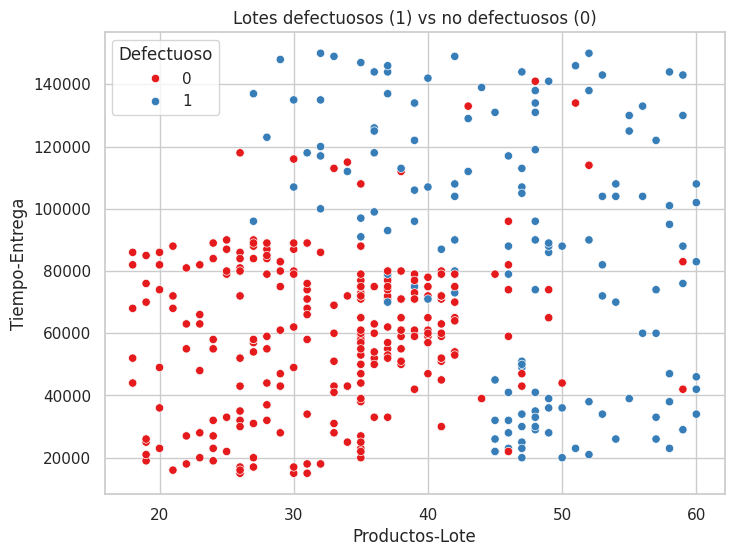

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Lote VS Productos",
    y="Tiempo VS Entrega",
    hue="Defectuoso o no defectuoso",
    palette="Set1"
)
plt.title("Lotes defectuosos (1) vs no defectuosos (0)")
plt.show()

In [ ]:
X1 = "ProductosVSLote"
X2 = "TiempoVSEntrega"
Y1 = "Defectuoso"

X = df[[X1, X2]].values
y = df[Y1].values

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3,random_state=2022,stratify=y)



NameError: name 'df' is not defined

In [ ]:
modelo_log = make_pipeline(
    StandardScaler(),
    LogisticRegression(solver="lbfgs")
)

modelo_log.fit(X_train, y_train)

Modelo entrenado correctamente.


In [ ]:
y_pred = modelo_log.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy  {acc:.3f}")

cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:")
print(cm)

print("clasificación:")
print(classification_report(y_test, y_pred))

Accuracy en test: 0.817

Matriz de confusión:
[[70  7]
 [15 28]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86        77
           1       0.80      0.65      0.72        43

    accuracy                           0.82       120
   macro avg       0.81      0.78      0.79       120
weighted avg       0.82      0.82      0.81       120



Curva ROC


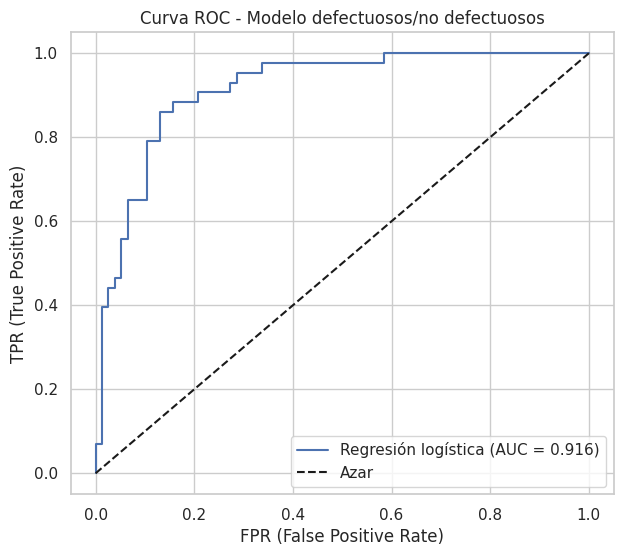

In [ ]:



y_prob = modelo_log.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"Regresión logística (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Azar")
plt.xlabel("FPR (False Positive Rate)")
plt.ylabel("TPR (True Positive Rate)")
plt.title("Curva ROC - Modelo defectuosos/no defectuosos")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Frontera de decision

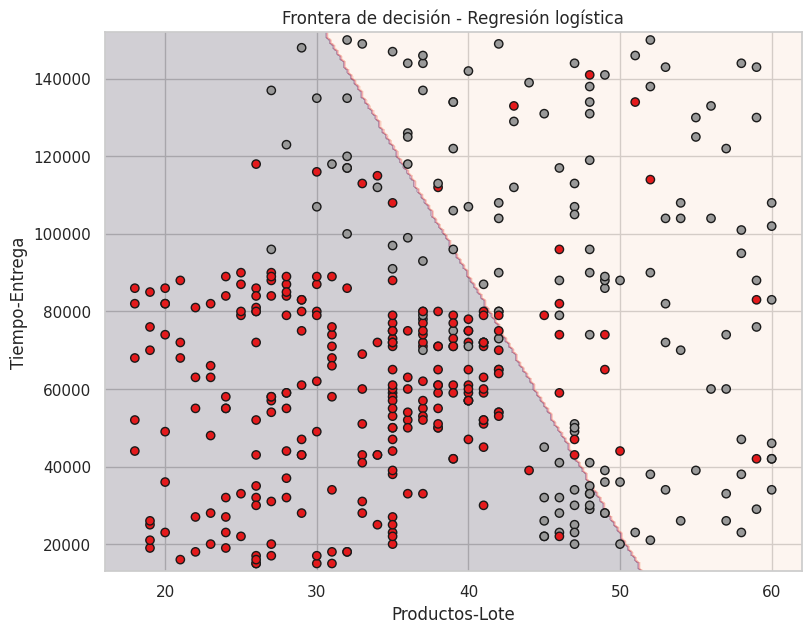

In [ ]:


x_min, x_max = df[X1].min() - 2, df[X1].max() + 2
y_min, y_max = df[X2].min() - 2000, df[X2].max() + 2000
n_points = 150
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, n_points),
    np.linspace(y_min, y_max, n_points)
)
Z = modelo_log.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.figure(figsize=(9,7))
plt.contourf(xx, yy, Z, alpha=0.2)
scatter = plt.scatter(
    df[X1],
    df[X2],
    c=df[Y1],
    edgecolor="k",
    cmap="Set1"
)

plt.xlabel(X1)
plt.ylabel(X2)
plt.title("Frontera de decisión - Regresión logística")
plt.show()
